In [2]:
import numpy as np
import matplotlib.pyplot as plt
import iris
import iris.quickplot as qplt
import xarray as xr
import glob
import cartopy.crs as ccrs

In [3]:
cmip6_files = sorted(glob.glob('../data/cmip6/*/zos_regression_ssp245_*.npy'))
cmip6_patts = np.zeros((len(cmip6_files), 180, 360))
for i, f in enumerate(cmip6_files):
    cmip6_patts[i] = np.load(f).data
    
cmip5_patt = np.load('../data/runs/cmip7_ensemble/data/zos_regression/zos_regression.npy')[2, 0]

print(cmip6_files)

['../data/cmip6/ACCESS-CM2/zos_regression_ssp245_ACCESS-CM2.npy', '../data/cmip6/ACCESS-ESM1-5/zos_regression_ssp245_ACCESS-ESM1-5.npy', '../data/cmip6/CMCC-CM2-SR5/zos_regression_ssp245_CMCC-CM2-SR5.npy', '../data/cmip6/CNRM-CM6-1-HR/zos_regression_ssp245_CNRM-CM6-1-HR.npy', '../data/cmip6/CNRM-CM6-1/zos_regression_ssp245_CNRM-CM6-1.npy', '../data/cmip6/CNRM-ESM2-1/zos_regression_ssp245_CNRM-ESM2-1.npy', '../data/cmip6/CanESM5-1/zos_regression_ssp245_CanESM5-1.npy', '../data/cmip6/CanESM5-CanOE/zos_regression_ssp245_CanESM5-CanOE.npy', '../data/cmip6/CanESM5/zos_regression_ssp245_CanESM5.npy', '../data/cmip6/EC-Earth3/zos_regression_ssp245_EC-Earth3.npy', '../data/cmip6/GISS-E2-1-G/zos_regression_ssp245_GISS-E2-1-G.npy', '../data/cmip6/GISS-E2-1-H/zos_regression_ssp245_GISS-E2-1-H.npy', '../data/cmip6/GISS-E2-2-G/zos_regression_ssp245_GISS-E2-2-G.npy', '../data/cmip6/INM-CM4-8/zos_regression_ssp245_INM-CM4-8.npy', '../data/cmip6/INM-CM5-0/zos_regression_ssp245_INM-CM5-0.npy', '../data

In [4]:
cmip6_files[-1]

'../data/cmip6/UKESM1-0-LL/zos_regression_ssp245_UKESM1-0-LL.npy'

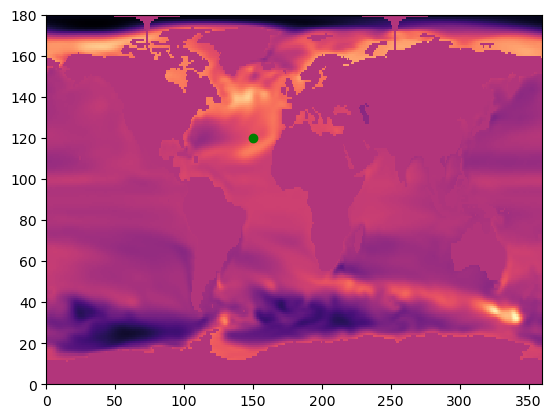

In [7]:
plt.pcolormesh(cmip6_patts[-1], cmap='magma')
# plt.scatter(26, 30, color='green')
plt.scatter(150, 120, color='green')
# plt.scatter(340, 170, color='green')

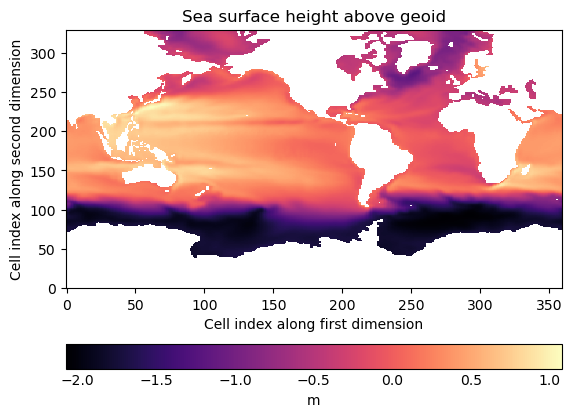

In [64]:
# Check the original zos and zostoga maps (UKESM1)
zos_ukesm = '/Users/gregorymunday/climate_data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Omon/zos/gn/v20190726/zos_Omon_UKESM1-0-LL_ssp585_r1i1p1f2_gn_201501-204912.nc'
zostoga_ukesm = '/Users/gregorymunday/climate_data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp585/r1i1p1f2/Omon/zostoga/gm/v20190819/zostoga_Omon_UKESM1-0-LL_ssp585_r1i1p1f2_gm_201501-204912.nc'

cube = iris.load_cube(zos_ukesm)

qplt.pcolormesh(cube[-2], cmap='magma')

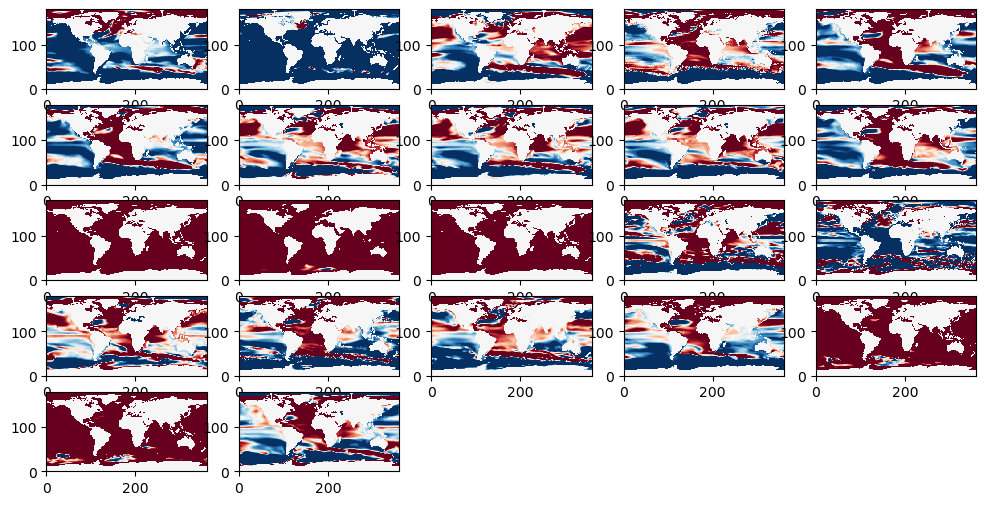

In [4]:
fig = plt.figure(figsize=(12, 6))


for i in range(len(cmip6_patts)):
    cmip6_patts[i] = np.roll(cmip6_patts[i], 180, axis=1)
    # Plot each pattern
    ax = plt.subplot(5, 5, i+ 1)
    ax.pcolormesh(cmip6_patts[i], cmap='RdBu_r', vmin=-0.2, vmax=0.2)


# plt.pcolormesh(np.roll(cmip6_patt, 180, axis=1), cmap='RdBu_r', vmin=-0.2, vmax=0.2)
# plt.colorbar(label='Sea Surface Height Regression (m)')
# plt.title('CMIP6')
plt.show()

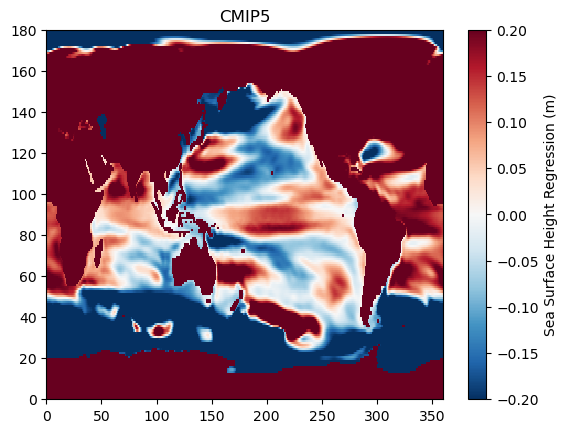

In [18]:
plt.pcolormesh(cmip5_patt, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
plt.colorbar(label='Sea Surface Height Regression (m)')
plt.title('CMIP5')
plt.show()

In [43]:
files = glob.glob('landwater/*.nc')
vals = []
lowers = []
uppers = []
labels = []
for f in files:
    ds = xr.load_dataset(f)
    ds = ds.interp(years=np.arange(2005, 2301, 1), method='linear').squeeze()
    vals.append(np.percentile(ds['sea_level_change'].values, 50, axis=0))
    lowers.append(np.percentile(ds['sea_level_change'].values, 17, axis=0))
    uppers.append(np.percentile(ds['sea_level_change'].values, 83, axis=0))
    labels.append(f.split('/')[-1].split('-')[-1][:6])
    
    

2300
SSP585 lower at 2100: 0.047m
SSP585 upper at 2100: 0.101m
SSP585 median at 2100: 0.074m


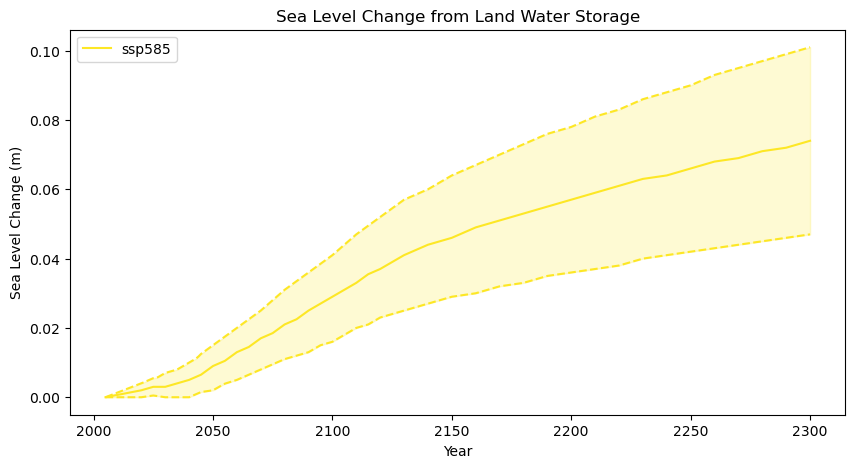

In [51]:
time = np.arange(2005, 2301, 1)
print(time[-1])

plt.figure(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(vals)))
for i, val in enumerate(vals):
    if not labels[i] == 'ssp585':
        continue
    plt.plot(time, val*0.001, color=colors[i], label=labels[i])
    plt.plot(time, lowers[i]*0.001, color=colors[i], linestyle='--')
    plt.plot(time, uppers[i]*0.001, color=colors[i], linestyle='--')
    plt.fill_between(time, np.array(lowers[i])*0.001, np.array(uppers[i])*0.001, color=colors[i], alpha=0.2)

    print(f'SSP585 lower at 2100: {lowers[i][-1] * 1e-3}m')
    print(f'SSP585 upper at 2100: {uppers[i][-1]* 1e-3}m')
    print(f'SSP585 median at 2100: {val[-1]* 1e-3}m')

plt.xlabel('Year')
plt.ylabel('Sea Level Change (m)')
plt.title('Sea Level Change from Land Water Storage')
plt.legend()
